# Results Analysis - DreamBooth vs LoRA vs Textual Inversion vs Baseline (FINAL)

Phân tích kết quả using final CLIP-based metrics (Similarity Version):
- **CLIP-content (Similarity)**: `cos_sim(output, content)` – Main metric (Higher is Better). Đo độ giữ nội dung.
- **CLIP-style (Similarity)**: `cos_sim(output, style_centroid)` – Main metric (Higher is Better). Đo độ giống phong cách.
- **Content Retention Rate** (trước đây là Style Strength): `CLIP-content / baseline_CLIP-content` – Tỷ lệ giữ nội dung so với ảnh gốc (Gần 1.0 là giống ảnh gốc, thấp hơn là style biến đổi mạnh).


## Setup

In [17]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RESULTS_DIR = Path("/kaggle/working/results/metrics")
if not RESULTS_DIR.exists():
    # Fallback path if needed
    RESULTS_DIR = Path(r"D:\HK5\CS431-KiThuaHocSau\DoAn\results\metrics")

METRICS_FILE = RESULTS_DIR / "all_metrics_final.csv"
METRICS_JSON = RESULTS_DIR / "all_metrics_final.json"

df_focus_models = None

print(f"Results directory: {RESULTS_DIR}")
print(f"Metrics CSV exists: {METRICS_FILE.exists()}")
print(f"Metrics JSON exists: {METRICS_JSON.exists()}")

Results directory: D:\HK5\CS431-KiThuaHocSau\DoAn\results\metrics
Metrics CSV exists: False
Metrics JSON exists: False


## Merge Metrics Files

In [18]:
LORA_METRICS_CSV = RESULTS_DIR / "lora_metrics_final.csv"
LORA_METRICS_JSON = RESULTS_DIR / "lora_metrics_final.json"
DREAMBOOTH_TI_METRICS_CSV = RESULTS_DIR / "dreambooth_ti_metrics_final.csv"
DREAMBOOTH_TI_METRICS_JSON = RESULTS_DIR / "dreambooth_ti_metrics_final.json"

required_cols = ["model", "clip_content", "clip_content_std", "style_strength"]

if LORA_METRICS_JSON.exists() and DREAMBOOTH_TI_METRICS_JSON.exists():
    print("Merging FINAL metrics files...")
    
    with open(LORA_METRICS_JSON, 'r', encoding='utf-8') as f:
        metrics_lora = json.load(f)
    with open(DREAMBOOTH_TI_METRICS_JSON, 'r', encoding='utf-8') as f:
        metrics_db_ti = json.load(f)
    
    df_lora = pd.DataFrame(metrics_lora).T
    df_lora.index.name = "model"
    df_lora = df_lora.reset_index()
    
    df_db_ti = pd.DataFrame(metrics_db_ti).T
    df_db_ti.index.name = "model"
    df_db_ti = df_db_ti.reset_index()
    
    # Validate columns
    for col in required_cols:
        if col not in df_lora.columns:
            # Fallback if metric missing (e.g. old format), though we expect new format
            print(f"Warning: {col} missing in LoRA metrics")
        if col not in df_db_ti.columns:
            print(f"Warning: {col} missing in DB/TI metrics")
    
    baseline_lora = df_lora[df_lora['model'] == 'baseline']
    baseline_db_ti = df_db_ti[df_db_ti['model'] == 'baseline']
    
    other_lora = df_lora[df_lora['model'] != 'baseline']
    other_db_ti = df_db_ti[df_db_ti['model'] != 'baseline']
    
    # Merge baseline (average if multiple baselines exist)
    bl_content = []
    bl_std = []
    if not baseline_lora.empty:
        bl_content.append(baseline_lora['clip_content'].values[0])
        bl_std.append(baseline_lora['clip_content_std'].values[0])
    if not baseline_db_ti.empty:
        bl_content.append(baseline_db_ti['clip_content'].values[0])
        bl_std.append(baseline_db_ti['clip_content_std'].values[0])
        
    baseline_dict = {
        'model': 'baseline',
        'clip_content': np.mean(bl_content) if bl_content else 0,
        'clip_content_std': np.mean(bl_std) if bl_std else 0,
        'style_strength': 1.0,
    }
    
    if 'clip_style' in df_lora.columns or 'clip_style' in df_db_ti.columns:
        baseline_dict['clip_style'] = np.nan
        baseline_dict['clip_style_std'] = np.nan
    
    baseline_avg = pd.DataFrame([baseline_dict])
    
    df_merged = pd.concat([baseline_avg, other_lora, other_db_ti], ignore_index=True)
    df_merged.to_csv(METRICS_FILE, index=False)
    print(f"Saved merged CSV: {METRICS_FILE}")
    print(f"Total models: {len(df_merged)}")
    
    # Merge JSON for backup
    merged_json = {}
    merged_json['baseline'] = baseline_dict
    for key, value in metrics_lora.items():
        if key != 'baseline': merged_json[key] = value
    for key, value in metrics_db_ti.items():
        if key != 'baseline': merged_json[key] = value
    
    with open(METRICS_JSON, 'w', encoding='utf-8') as f:
        json.dump(merged_json, f, indent=2)
    
    print("\nMerged metrics preview:")
    pd.set_option('display.max_columns', None)
    print(df_merged.head(10))
elif METRICS_FILE.exists():
    print(f"Using existing merged file: {METRICS_FILE}")
else:
    print("Warning: Could not find final metrics JSON files")
    print("Please run 04a and 04b notebooks first.")

Merging FINAL metrics files...
Saved merged CSV: D:\HK5\CS431-KiThuaHocSau\DoAn\results\metrics\all_metrics_final.csv
Total models: 9

Merged metrics preview:
                            model  clip_content  clip_content_std  \
0                        baseline      0.591125          0.051982   
1             lora_actionpainting      0.584656          0.063845   
2           lora_analyticalcubism      0.570129          0.064752   
3        lora_contemporaryrealism      0.573944          0.062330   
4                 lora_newrealism      0.580170          0.072603   
5            lora_syntheticcubism      0.570374          0.062488   
6  dreambooth_contemporaryrealism      0.568024          0.057857   
7           dreambooth_newrealism      0.555817          0.058803   
8                     ti_sksstyle      0.571106          0.049227   

   style_strength  clip_style  clip_style_std  
0        1.000000         NaN             NaN  
1        0.989055    0.701050        0.039834  
2     

## Load Metrics

In [19]:
if METRICS_FILE.exists():
    df = pd.read_csv(METRICS_FILE)
    print("Loaded from CSV")
elif METRICS_JSON.exists():
    with open(METRICS_JSON, 'r', encoding='utf-8') as f:
        metrics_dict = json.load(f)
    df = pd.DataFrame(metrics_dict).T
    df.index.name = "model"
    df = df.reset_index()
    print("Loaded from JSON")
else:
    df = None

if df is not None:
    print(f"\nShape: {df.shape}")
    baseline_row = df[df['model'] == 'baseline']
    baseline_clip = baseline_row['clip_content'].values[0] if not baseline_row.empty else np.nan
    if baseline_row.empty or baseline_clip == 0:
        df['content_retention_rate'] = np.nan
    else:
        df['content_retention_rate'] = df['clip_content'] / baseline_clip
    display_df = df.copy()
    display_cols = ['model', 'clip_content', 'content_retention_rate']
    if 'clip_style' in df.columns:
        display_cols.append('clip_style')
    print("\n" + "="*80)
    print("FULL METRICS TABLE (Similarity: 0-1, Higher is Better)")
    print("="*80)
    print(display_df[display_cols].round(4).to_string(index=False))
    def _extract_style_key(name: str) -> str:
        lowered = name.lower()
        if lowered == 'baseline':
            return 'baseline'
        return re.sub(r'^(dreambooth_|lora_|ti_|textualinversion_|textual_)', '', lowered)
    df['style_key'] = df['model'].apply(_extract_style_key)
    df['style_pretty'] = df['style_key'].apply(lambda x: x.replace('_', ' ').title())
    lora_styles = set(df[df['model'].str.contains('lora_', case=False)]['style_key'])
    dream_styles = set(df[df['model'].str.contains('dreambooth_', case=False)]['style_key'])
    shared_styles = sorted(list(lora_styles & dream_styles))
    if shared_styles:
        print(f"\nShared Styles found: {shared_styles}")
    focus_styles = ['contemporaryrealism', 'newrealism']
    focus_mask = (
        (df['model'] == 'baseline') |
        df['model'].str.contains('ti_', case=False) |
        (
            df['style_key'].isin(focus_styles) &
            (
                df['model'].str.contains('lora_', case=False) |
                df['model'].str.contains('dreambooth_', case=False)
            )
        )
    )
    df_focus_models = df[focus_mask].copy()
    if not df_focus_models.empty:
        df_focus_models['style_pretty'] = df_focus_models['style_key'].apply(lambda x: x.replace('_', ' ').title())
else:
    df_focus_models = None

Loaded from CSV

Shape: (9, 6)

FULL METRICS TABLE (Similarity: 0-1, Higher is Better)
                         model  clip_content  content_retention_rate  clip_style
                      baseline        0.5911                  1.0000         NaN
           lora_actionpainting        0.5847                  0.9891      0.7010
         lora_analyticalcubism        0.5701                  0.9645      0.7106
      lora_contemporaryrealism        0.5739                  0.9709      0.6731
               lora_newrealism        0.5802                  0.9815      0.6371
          lora_syntheticcubism        0.5704                  0.9649      0.7373
dreambooth_contemporaryrealism        0.5680                  0.9609      0.6883
         dreambooth_newrealism        0.5558                  0.9403      0.6965
                   ti_sksstyle        0.5711                  0.9661      0.6704

Shared Styles found: ['contemporaryrealism', 'newrealism']


## Visualization - Metrics Comparison (Updated)

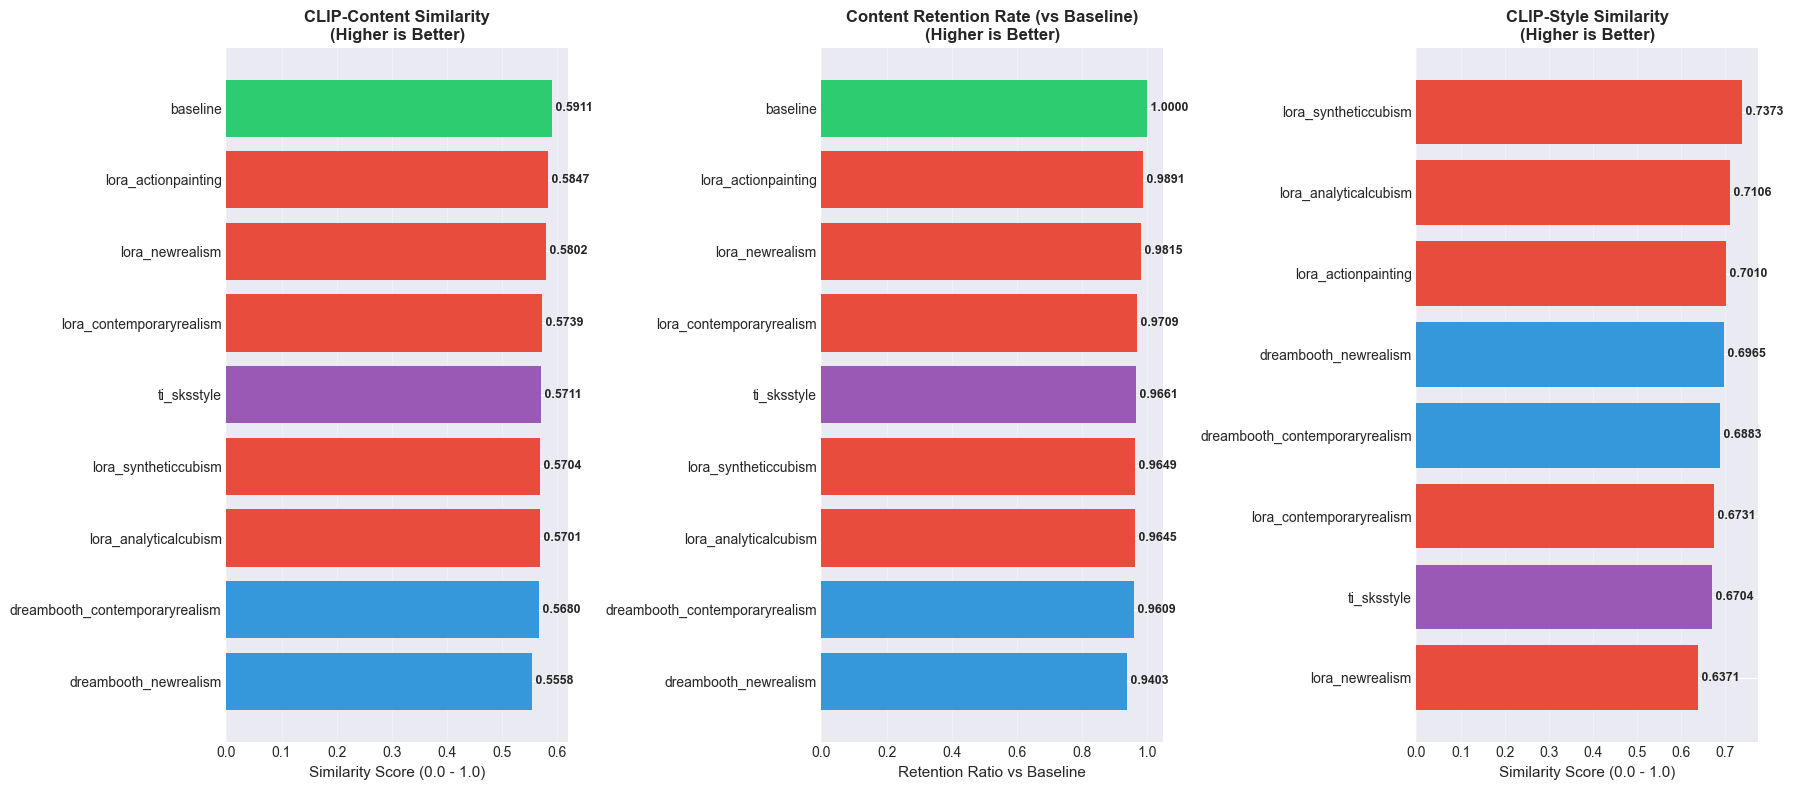

Saved plot: D:\HK5\CS431-KiThuaHocSau\DoAn\results\metrics\metrics_comparison_similarity.png


In [20]:
if df is not None:
    has_style_metrics = 'clip_style' in df.columns and df['clip_style'].notna().any()
    
    # Define metrics configuration
    # (Metric Column, Title, Ascending Sort for Plot)
    # Note: For horizontal bar plot, "True" sorting usually puts smallest at top, largest at bottom.
    metrics_to_plot = [
        ('clip_content', 'CLIP-Content Similarity\n(Higher is Better)', True),
        ('content_retention_rate', 'Content Retention Rate (vs Baseline)\n(Higher is Better)', True),
    ]
    
    if has_style_metrics:
        metrics_to_plot.append(('clip_style', 'CLIP-Style Similarity\n(Higher is Better)', True))
    
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 8))
    if len(metrics_to_plot) == 1:
        axes = [axes]
    
    for idx, (metric, title, ascending) in enumerate(metrics_to_plot):
        ax = axes[idx]
        data = df[['model', metric]].dropna(subset=[metric]).sort_values(metric, ascending=ascending)
        
        if len(data) == 0: continue
            
        colors = []
        for m in data['model']:
            if 'baseline' in m.lower(): colors.append('#2ecc71')
            elif 'dreambooth' in m.lower(): colors.append('#3498db')
            elif 'ti_' in m.lower() or 'textual' in m.lower(): colors.append('#9b59b6')
            else: colors.append('#e74c3c')

        bars = ax.barh(data['model'], data[metric], color=colors)
        
        x_label = "Similarity Score (0.0 - 1.0)" if metric != 'content_retention_rate' else "Retention Ratio vs Baseline"
        ax.set_xlabel(x_label, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        
        for i, (bar, val) in enumerate(zip(bars, data[metric])):
            ax.text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')
            
    plt.tight_layout()
    save_path = RESULTS_DIR / "metrics_comparison_similarity.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved plot: {save_path}")

## Model Type Comparison

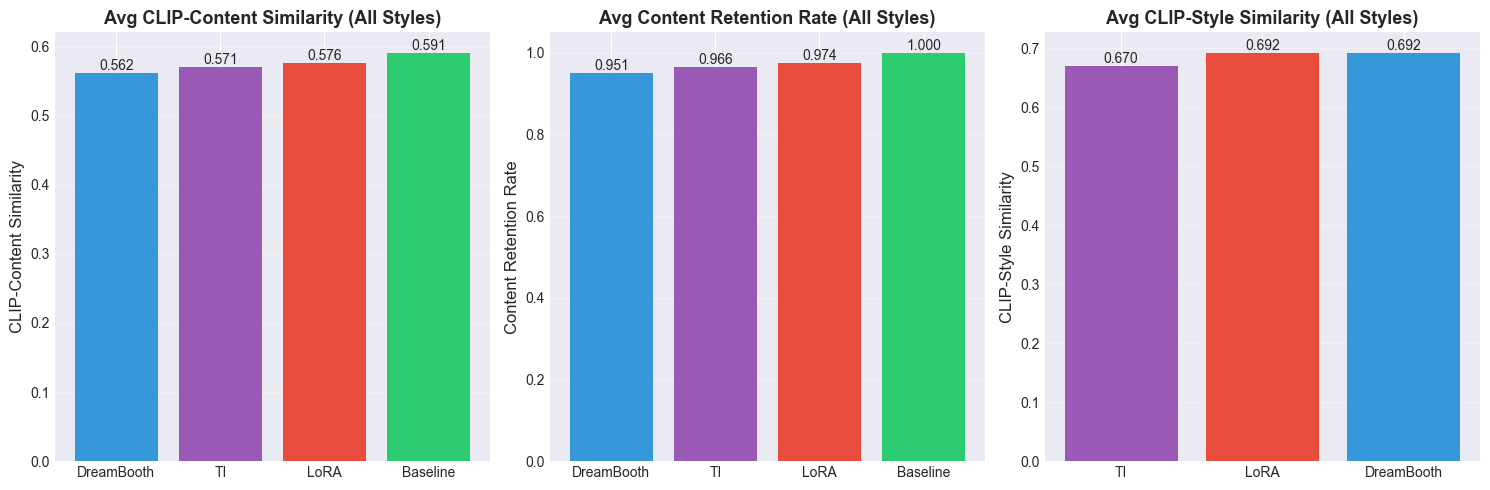

In [21]:
if df is not None and 'style_key' in df.columns:
    df_model_compare = df.copy()
    df_model_compare['model_type'] = df_model_compare['model'].apply(lambda x:
        'Baseline' if 'baseline' in x.lower()
        else 'DreamBooth' if 'dreambooth' in x.lower()
        else 'LoRA' if 'lora' in x.lower()
        else 'TI' if 'ti_' in x.lower() or 'textual' in x.lower()
        else 'Other')
    metrics_config = [
        ('clip_content', 'CLIP-Content Similarity', True),
        ('content_retention_rate', 'Content Retention Rate', True),
    ]
    if 'clip_style' in df_model_compare.columns and df_model_compare['clip_style'].notna().any():
        metrics_config.append(('clip_style', 'CLIP-Style Similarity', True))
    fig, axes = plt.subplots(1, len(metrics_config), figsize=(5 * len(metrics_config), 5))
    if len(metrics_config) == 1:
        axes = [axes]
    for idx, (metric, name, ascending) in enumerate(metrics_config):
        ax = axes[idx]
        model_type_data = df_model_compare.groupby('model_type')[metric].mean().dropna().sort_values(ascending=ascending)
        if len(model_type_data) == 0:
            continue
        bars = ax.bar(model_type_data.index, model_type_data.values, 
             color=['#2ecc71' if 'baseline' in m.lower() 
                    else '#3498db' if 'dreambooth' in m.lower() 
                    else '#e74c3c' if 'lora' in m.lower()
                    else '#9b59b6'
                    for m in model_type_data.index])
        ax.set_ylabel(name, fontsize=12)
        ax.set_title(f'Avg {name} (All Styles)', fontsize=13, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, model_type_data.values):
            ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "model_type_comparison_similarity_all.png", dpi=150, bbox_inches='tight')
    plt.show()

## Comparison with Baseline (Delta)

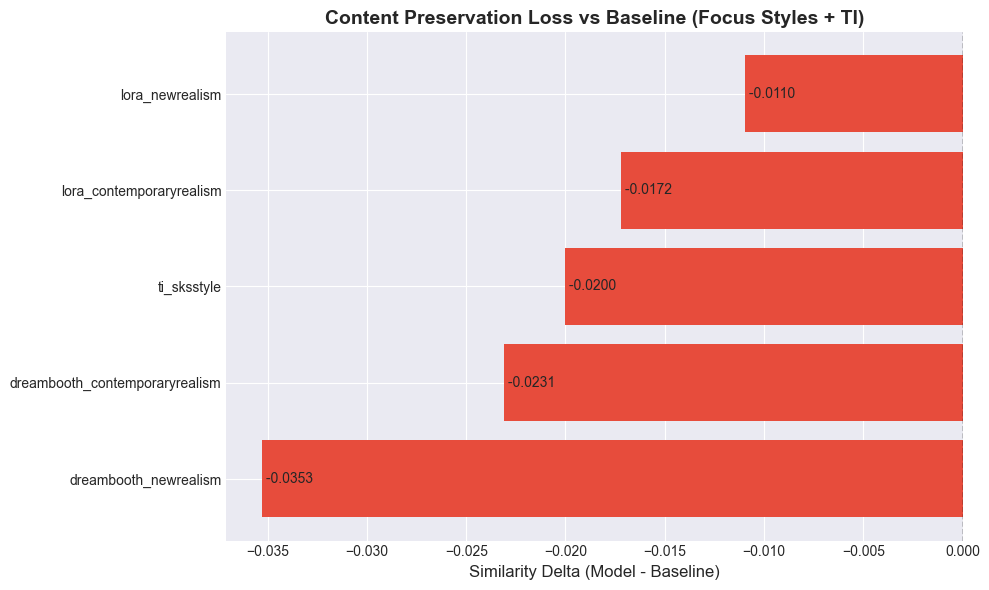

In [22]:
if df is not None:
    comparison_df = df_focus_models if df_focus_models is not None and not df_focus_models.empty else df
    baseline_row = comparison_df[comparison_df['model'] == 'baseline']
    if not baseline_row.empty:
        baseline_clip = baseline_row['clip_content'].values[0]
        other_models = comparison_df[comparison_df['model'] != 'baseline'].copy()
        other_models['clip_delta'] = other_models['clip_content'] - baseline_clip
        fig, ax = plt.subplots(figsize=(10, 6))
        data = other_models.sort_values('clip_delta', ascending=True)
        bars = ax.barh(data['model'], data['clip_delta'], color='#e74c3c')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel("Similarity Delta (Model - Baseline)", fontsize=12)
        ax.set_title("Content Preservation Loss vs Baseline (Focus Styles + TI)", fontsize=14, fontweight='bold')
        for i, (bar, val) in enumerate(zip(bars, data['clip_delta'])):
            ax.text(val, i, f' {val:+.4f}', va='center', fontsize=10)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "baseline_delta_similarity_focus.png", dpi=150, bbox_inches='tight')
        plt.show()

## Style Analysis (Shared Styles)

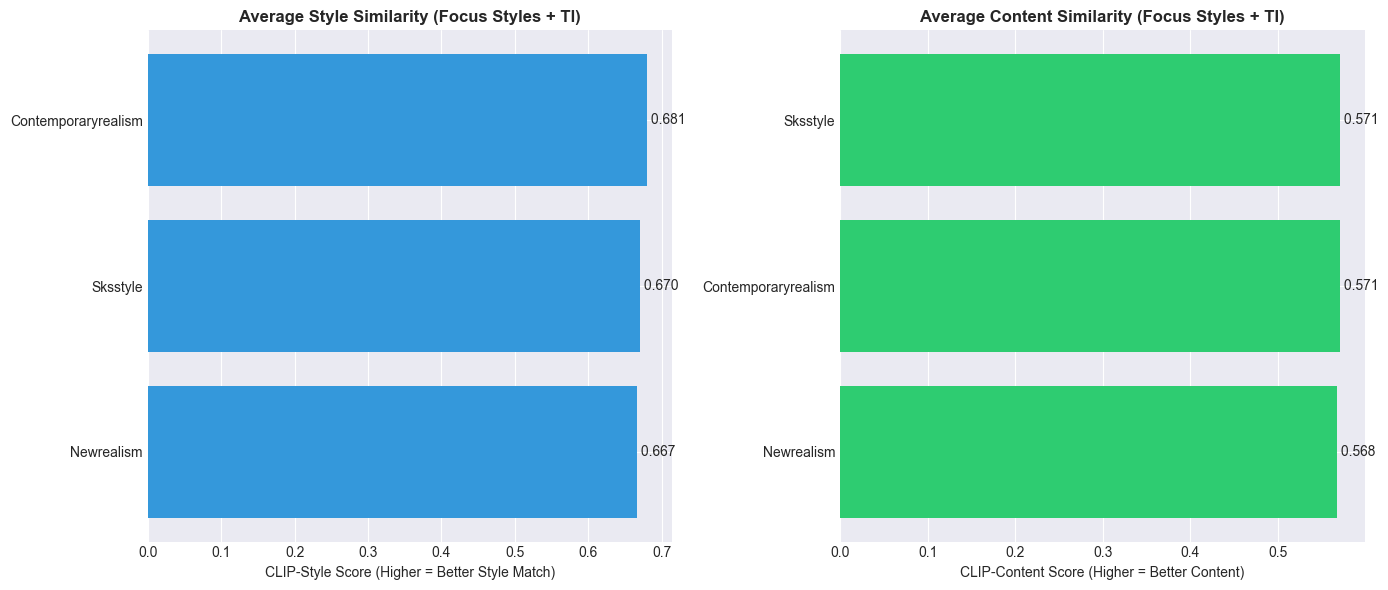

In [23]:
if df_focus_models is not None and not df_focus_models.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    if 'clip_style' in df_focus_models.columns and df_focus_models['clip_style'].notna().any():
        ax = axes[0]
        style_data = df_focus_models[df_focus_models['model'] != 'baseline'].groupby('style_pretty')['clip_style'].mean().sort_values(ascending=True)
        bars = ax.barh(style_data.index, style_data.values, color='#3498db')
        ax.set_title("Average Style Similarity (Focus Styles + TI)", fontweight='bold')
        ax.set_xlabel("CLIP-Style Score (Higher = Better Style Match)")
        for i, v in enumerate(style_data.values):
            ax.text(v, i, f' {v:.3f}', va='center')
    else:
        axes[0].set_axis_off()
    ax = axes[1]
    content_data = df_focus_models[df_focus_models['model'] != 'baseline'].groupby('style_pretty')['clip_content'].mean().sort_values(ascending=True)
    bars = ax.barh(content_data.index, content_data.values, color='#2ecc71')
    ax.set_title("Average Content Similarity (Focus Styles + TI)", fontweight='bold')
    ax.set_xlabel("CLIP-Content Score (Higher = Better Content)")
    for i, v in enumerate(content_data.values):
        ax.text(v, i, f' {v:.3f}', va='center')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "style_analysis_similarity_focus.png", dpi=150, bbox_inches='tight')
    plt.show()

## Summary Text Report

In [24]:
if df is not None:
    summary_df = df_focus_models if df_focus_models is not None and not df_focus_models.empty else df
    print("="*80)
    print("RESULTS SUMMARY (Similarity Metrics)")
    print("="*80)
    baseline_row = summary_df[summary_df['model'] == 'baseline']
    if not baseline_row.empty:
        print(f"Baseline CLIP-Content: {baseline_row['clip_content'].values[0]:.4f}")
    non_baseline = summary_df[summary_df['model'] != 'baseline']
    if not non_baseline.empty:
        best_content = non_baseline.sort_values('clip_content', ascending=False).iloc[0]
        print(f"\nBest Content Retention: {best_content['model']} (Score: {best_content['clip_content']:.4f})")
        if 'clip_style' in summary_df.columns:
            best_style = non_baseline.sort_values('clip_style', ascending=False).iloc[0]
            print(f"Best Style Match:      {best_style['model']} (Score: {best_style['clip_style']:.4f})")
        if 'clip_style' in summary_df.columns:
            balance_df = summary_df.copy()
            balance_df['balance_score'] = balance_df['clip_content'] * balance_df['clip_style']
            best_balance = balance_df[balance_df['model'] != 'baseline'].sort_values('balance_score', ascending=False).iloc[0]
            print(f"Best Balance:          {best_balance['model']} (Combined: {best_balance['balance_score']:.4f})")

RESULTS SUMMARY (Similarity Metrics)
Baseline CLIP-Content: 0.5911

Best Content Retention: lora_newrealism (Score: 0.5802)
Best Style Match:      dreambooth_newrealism (Score: 0.6965)
Best Balance:          dreambooth_contemporaryrealism (Combined: 0.3910)
